# EURNOK V. EURSEK

### IMPORT

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE

### PARAMS

In [2]:
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Keep: Captures the short-term microstructure beta
Z_WINDOW = 100              # Keep: Fast rolling mean to fade bid/ask bounces

ENTRY_Z = 1.50              # TWEAKED: Raised from 1.25
EXIT_Z = -0.25              # Keep: Captures momentum past the mean
AR_LIMIT = 0.985            # TWEAKED: Tightened from 0.995
DANGER_THRESHOLD = 0.95     # TWEAKED: Raised from 0.90

### DESCRIPTIVE

built 16027 rows

=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=1.78 | B=1.33 bps


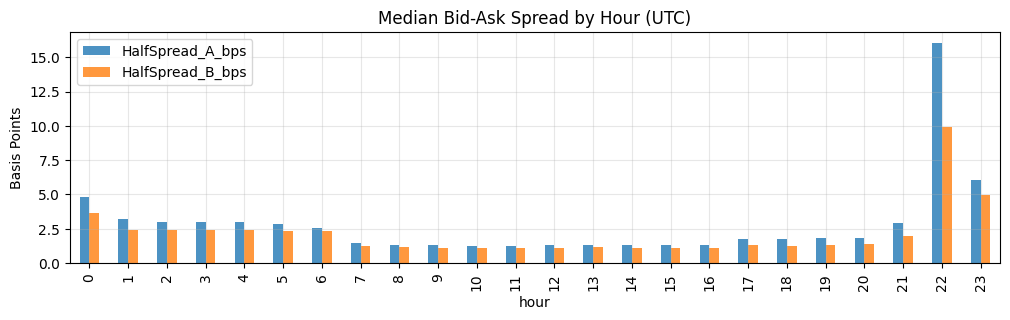


=== RETURN STATISTICS (Log Scale) ===
         Mean (bps)  Vol (bps)      Skew   Kurtosis
EUR/NOK    0.013468   2.787789 -0.047015   5.157068
EUR/SEK    0.004545   2.296403 -0.184318  11.139117

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


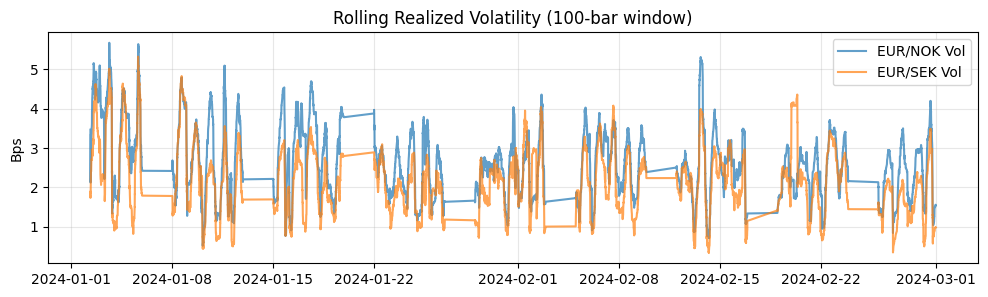

In [3]:
eda_months = ["202401", "202402"]
eda_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in eda_months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in eda_months],
]

# 2. Build 24-hours for the EDA
builder_eda = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24)) 
df_raw_eda = builder_eda.build(eda_files)

# 3. Run Descriptive Stats to see the Bar Chart
eda = DESCRIPTIVE(df_raw_eda, "EUR/NOK", "EUR/SEK")
eda.generate_full_eda()

### DATA

In [ ]:
months = [
    # "202401", "202402", "202403", "202404", "202405", "202406",
    # "202407", "202408", "202409", "202410", "202411", "202412",
    # "202501", "202502", "202503", "202504", "202505", "202506",
    # "202507", "202508", "202509", "202510", "202511", 
    "202512"
]

my_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

In [ ]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(9, 15)) # Build all hours first
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE

In [ ]:
eda = DESCRIPTIVE(df, name_a="EURNOK", name_b="EURSEK")
eda.generate_full_eda()

### SCREENER

In [ ]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [ ]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [ ]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW
)

In [ ]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)

In [ ]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()